<a href="https://colab.research.google.com/github/huyphucc/nova-bank-credit-risk/blob/main/nova_bank_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load từ GitHub — permanent link, không mất khi Colab reset
URL = "https://raw.githubusercontent.com/huyphucc/nova-bank-credit-risk/main/data/processed/credit_risk_clean.csv"
df = pd.read_csv(URL)

# Verify load đúng
print(f"Shape: {df.shape}")
print(f"Default rate: {df['loan_status'].mean():.4f} ({df['loan_status'].mean()*100:.2f}%)")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (32576, 38)
Default rate: 0.2182 (21.82%)
Columns: ['client_ID', 'person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'gender', 'marital_status', 'education_level', 'employment_type', 'age_bucket', 'income_bucket', 'log_income', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_term_months', 'is_subprime', 'loan_percent_income', 'other_debt', 'log_other_debt', 'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio', 'lpi_bucket', 'dti_bucket', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'past_delinquencies', 'has_prior_default', 'thin_file', 'country', 'state', 'city', 'city_latitude', 'city_longitude', 'is_homeowner', 'loan_status']


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,gender,marital_status,education_level,employment_type,age_bucket,...,past_delinquencies,has_prior_default,thin_file,country,state,city,city_latitude,city_longitude,is_homeowner,loan_status
0,CUST_00001,22,59000,RENT,50.0,Male,Married,High School,Self-employed,20-25,...,0,1,0,Canada,Ontario,Toronto,43.6532,-79.3832,0,1
1,CUST_00002,21,9600,OWN,5.0,Female,Divorced,Master,Full-time,20-25,...,3,0,1,Canada,Ontario,Toronto,43.6532,-79.3832,1,0
2,CUST_00003,25,9600,MORTGAGE,1.0,Female,Married,Master,Full-time,20-25,...,0,0,0,UK,Wales,Swansea,51.6214,-3.9436,1,1
3,CUST_00004,23,65500,RENT,4.0,Male,Married,Bachelor,Part-time,20-25,...,0,0,1,Canada,BC,Vancouver,49.2827,-123.1207,0,1
4,CUST_00005,24,54400,RENT,8.0,Female,Single,Bachelor,Part-time,20-25,...,0,1,0,USA,New York,Buffalo,42.8864,-78.8784,0,1


# Nova Bank — Credit Risk Analytics

## Project Overview

**Business Context:** Nova Bank is a personal lending institution operating
across the US, UK, and Canada. The bank currently faces a **21.82% default
rate** on its loan portfolio — understanding the drivers of default and
identifying safer borrower segments is critical to sustainable growth.

**Big Question:** How can Nova Bank optimize lending decisions to reduce
default losses **AND** identify higher-quality borrower segments through data?

**Scope:**
- 32,576 cleaned loan records (originally 32,581, 5 age outliers removed)
- 38 features across 7 functional groups: Demographics, Loan Characteristics,
  Risk Ratios, Credit Bureau, Geographic, plus 10 engineered features
- Personal loans only, term 12–60 months

**Methodology:** SQL (data cleaning) → Python (EDA, clustering, WoE/IV) →
Power BI (business dashboard)

**Analytical Framework:** This analysis follows a bias-free Issue Tree with
14 testable hypotheses across 3 branches:
- 🔴 **Risk Mitigation** — what factors drive default, where are the thresholds?
- 🟢 **Growth Opportunity** — can we find low-risk segments to expand into?
- 🟡 **Data Integrity** — are there synthetic artifacts or quality issues
  that could distort findings?

---
*Author: Dang Huy Phuc — Fintech 2026, National Economics University Hanoi*

In [3]:
# ═══════════════════════════════════════════════════════════════
# SECTION 2 — DATASETS OVERVIEW
# ═══════════════════════════════════════════════════════════════

# ─── 2.1 Schema summary ──────────────────────────────────────────
print("="*60)
print("DATASET SHAPE & SCHEMA")
print("="*60)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()

dtype_summary = df.dtypes.value_counts()
print("Data types breakdown:")
print(dtype_summary)
print()

# ─── 2.2 Missing value check (should be zero — cleaned in SQL) ──
print("="*60)
print("MISSING VALUES (should be 0 — cleaning done in SQL)")
print("="*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0]
if missing_summary.empty:
    print("✅ Zero missing values — SQL cleaning pipeline successful.")
else:
    print(missing_summary)
print()

# ─── 2.3 Target distribution ─────────────────────────────────────
print("="*60)
print("TARGET DISTRIBUTION (loan_status)")
print("="*60)
target_dist = df['loan_status'].value_counts()
target_pct = df['loan_status'].value_counts(normalize=True) * 100
print(f"Non-default (0): {target_dist[0]:,} ({target_pct[0]:.2f}%)")
print(f"Default (1):     {target_dist[1]:,} ({target_pct[1]:.2f}%)")
print()

# ─── 2.4 Quick numeric summary ───────────────────────────────────
print("="*60)
print("NUMERIC COLUMNS SUMMARY")
print("="*60)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

DATASET SHAPE & SCHEMA
Rows: 32,576
Columns: 38

Data types breakdown:
object     16
int64      12
float64    10
Name: count, dtype: int64

MISSING VALUES (should be 0 — cleaning done in SQL)
✅ Zero missing values — SQL cleaning pipeline successful.

TARGET DISTRIBUTION (loan_status)
Non-default (0): 25,468 (78.18%)
Default (1):     7,108 (21.82%)

NUMERIC COLUMNS SUMMARY


,count,mean,std,min,25%,50%,75%,max
person_age,32576.0,27.718044,6.204990,20.000000,23.000000,26.000000,30.000000,94.000000
person_income,32576.0,64320.869413,37780.467373,4000.000000,38500.000000,55000.000000,79200.000000,225200.000000
person_emp_length,32576.0,4.763353,3.996809,0.000000,2.000000,4.000000,7.000000,50.000000
log_income,32576.0,10.920855,0.551988,8.294300,10.558439,10.915107,11.279744,12.324749
loan_amnt,32576.0,9589.117755,6321.886846,500.000000,5000.000000,8000.000000,12200.000000,35000.000000
loan_int_rate,32576.0,11.013773,3.212454,5.420000,7.880000,10.990000,13.480000,23.220000
loan_term_months,32576.0,38.501965,16.012811,12.000000,24.000000,36.000000,60.000000,60.000000
is_subprime,32576.0,0.150264,0.357335,0.000000,0.000000,0.000000,0.000000,1.000000
loan_percent_income,32576.0,0.170212,0.106778,0.000000,0.090000,0.150000,0.230000,0.830000
other_debt,32576.0,11529.404630,11315.622606,225.207400,5386.246350,8994.217900,14559.804475,399125.753000


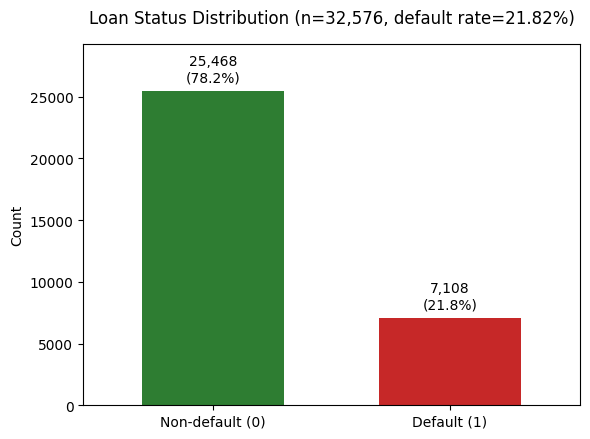

In [4]:
# ─── 2.5 Visualize target distribution (FIXED) ───────────────────
fig, ax = plt.subplots(figsize=(6, 4.5))
target_dist.plot(kind='bar', ax=ax, color=['#2E7D32', '#C62828'], width=0.6)
ax.set_xticklabels(['Non-default (0)', 'Default (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_xlabel('')  # bỏ label "loan_status" thừa ở trục x
ax.set_title(f'Loan Status Distribution (n={len(df):,}, default rate={target_pct[1]:.2f}%)',
             pad=15)  # thêm khoảng cách giữa title và plot

# Tăng ylim để có chỗ cho data label phía trên bar cao nhất
ax.set_ylim(0, target_dist.max() * 1.15)

for i, v in enumerate(target_dist):
    ax.text(i, v + target_dist.max()*0.02, f'{v:,}\n({target_pct[i]:.1f}%)',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 2.1 Feature Groups

| Group | Columns | Count |
|---|---|---|
| **Identifier** | client_ID | 1 |
| **Demographics** | person_age, person_income, person_home_ownership, person_emp_length, gender, marital_status, education_level, employment_type, age_bucket, income_bucket, log_income | 11 |
| **Loan Characteristics** | loan_intent, loan_grade, loan_amnt, loan_int_rate, loan_term_months, is_subprime | 6 |
| **Risk Ratios** | loan_percent_income, other_debt, log_other_debt, debt_to_income_ratio, open_accounts, credit_utilization_ratio, lpi_bucket, dti_bucket | 8 |
| **Credit Bureau** | cb_person_default_on_file, cb_person_cred_hist_length, past_delinquencies, has_prior_default, thin_file | 5 |
| **Geographic** | country, state, city, city_latitude, city_longitude, is_homeowner | 6 |
| **Target** | loan_status | 1 |

⚠️ **Excluded from modeling** (kept for descriptive/fairness analysis only):
`gender`, `marital_status`, `education_level` (protected variables — ECOA
compliance), `loan_grade` (circular logic — output of existing scoring system)

## Section 3 — Terms & Metrics

Glossary of credit risk terminology used throughout this analysis.

### Target & Outcome Metrics

| Term | Definition |
|---|---|
| **Default** | Borrower fails to repay the loan as agreed (`loan_status = 1`) |
| **Default Rate** | % of loans that end in default = `defaults / total loans` |
| **NPL (Non-Performing Loan)** | Industry term for a loan in/near default; synonymous with "default" here |

### Borrower Risk Ratios

| Term | Definition | Formula |
|---|---|---|
| **DTI (Debt-to-Income)** | Total debt burden relative to income — higher DTI = less repayment capacity | `total_debt / income` |
| **LPI (Loan Payment to Income)** | This loan's size relative to income — also called `loan_percent_income` | `loan_amnt / income` |
| **Credit Utilization Ratio** | % of available credit currently in use | `balance / credit_limit` |
| **Thin File** | Borrower with limited credit history (< 3 years here), making risk harder to assess | — |

### Credit Scoring Concepts

| Term | Definition |
|---|---|
| **Loan Grade** | Risk tier assigned by Nova Bank's current scoring system (A=lowest risk → G=highest risk). This is an *output* of the existing system, not a raw input — used here only to validate the new analysis, not as a model feature (avoids circular logic) |
| **WoE (Weight of Evidence)** | A technique that measures how well a variable separates good vs. bad borrowers, used to transform categorical/binned variables for scoring models |
| **IV (Information Value)** | Summarizes a feature's overall predictive power based on its WoE; rule of thumb: IV < 0.02 = not useful, 0.02–0.3 = useful, > 0.3 = potentially too good (check for leakage) |

### Risk Quantification (referenced conceptually, not modeled in this phase)

| Term | Definition |
|---|---|
| **PD (Probability of Default)** | The likelihood (0–1) that a borrower will default, typically the output of a predictive model |
| **LGD (Loss Given Default)** | % of exposure the lender loses if a borrower defaults (assumption: 40% for unsecured personal loans, industry standard) |
| **EAD (Exposure at Default)** | The outstanding loan balance at the time of default |
| **EL (Expected Loss)** | `PD × LGD × EAD` — the average loss a lender expects to absorb |

### Statistical / Methodology Terms

| Term | Definition |
|---|---|
| **MCAR (Missing Completely At Random)** | Missing values with no relationship to any other variable — safe to impute with simple methods like group medians |
| **Multicollinearity** | When two or more features are highly correlated, causing instability in regression coefficients |
| **Class Imbalance** | When one outcome class is much rarer than the other (here: 21.82% default vs. 78.18% non-default) — mild enough that `class_weight='balanced'` is sufficient, no need for oversampling (SMOTE) |
| **Winsorization** | Capping extreme outlier values at a percentile threshold (e.g., 99th) instead of removing them, to reduce their distorting effect on means/models |

### Regulatory Reference

| Term | Definition |
|---|---|
| **QM Rule (Qualified Mortgage Rule)** | US regulatory benchmark capping DTI at 43% for "qualified" loans — used here only as a *post-hoc* benchmark, not as a pre-determined threshold (thresholds in this analysis are found from the data first) |
| **ECOA (Equal Credit Opportunity Act)** | US law prohibiting credit decisions based on protected characteristics (gender, marital status, etc.) — basis for excluding these variables from any predictive model in this analysis |

## Section 4 — Approaches

### 4.1 Analytical Framework — 3-Tier Roadmap

This analysis progresses through three tiers of increasing depth:

| Tier | Question Answered | Sections |
|---|---|---|
| **Descriptive** | What does the data look like? | 2, 7.2 |
| **Diagnostic** | Why does default happen? Which factors matter? | 7.3, 7.4, 7.6 |
| **Predictive / Prescriptive** | What threshold/policy minimizes risk while maximizing approvals? | 7.5 |

### 4.2 Tool Chain

| Stage | Tool | Rationale |
|---|---|---|
| Data Cleaning | **SQL** (SQL Server 2022, Docker) | Mirrors production banking environments; explicit, auditable transformation logic |
| EDA & Analysis | **Python** (Pandas, Seaborn, Scikit-learn) | Rich statistical/ML ecosystem; WoE/IV, clustering, modeling |
| Business Reporting | **Power BI** | Stakeholder-facing dashboard; standard in banking analytics teams |

Each tool is used for what it does best, rather than forcing one tool to do everything — a deliberate choice reflecting how analytics teams typically operate.

### 4.3 Data Cleaning Summary (full detail in SQL repo)

The following transformations were applied in SQL prior to this notebook
(see `sql/04_data_cleaning.sql` in the [GitHub repo](https://github.com/huyphucc/nova-bank-credit-risk)):

| # | Transformation | Why |
|---|---|---|
| T1 | Removed 5 rows with `person_age > 100` | Biologically implausible outliers |
| T2 | Imputed missing `person_emp_length` with group median (by `employment_type`) | Data showed Unemployed borrowers have similar tenure to other groups (~4.7 yrs) — imputing 0 would have created artificial outliers |
| T3 | Winsorized `person_income` at the 99th percentile | Prevents extreme incomes (max was $6M) from distorting linear model coefficients |
| T4 | Median-imputed `loan_int_rate` by `loan_grade` | Missingness confirmed MCAR (uniform ~9-11% across grades); group median preserves the risk-based pricing relationship |
| T5 | Dropped `loan_to_income_ratio` | Pearson correlation with `loan_percent_income` = 0.999 — functionally redundant, would cause multicollinearity |

10 derived features (buckets, log-transforms, binary flags) were also created
in SQL — see column list in Section 2.

### 4.4 Anti-Bias Commitments

This analysis follows explicit rules to avoid motivated reasoning:

1. **Hypotheses, not conclusions.** Every question in the Issue Tree is
   phrased as something to test, not something assumed true.
2. **Thresholds from data first.** Cutoffs (e.g., for DTI, LPI) are derived
   from the data's own distribution before being compared to external
   benchmarks (e.g., the US Qualified Mortgage 43% DTI rule).
3. **No premature dismissal.** Features with surprisingly low correlation
   (`past_delinquencies`, `credit_utilization_ratio`) are not dropped
   outright — they are tested via WoE/IV and checked for multicollinearity
   before being labeled non-predictive.
4. **Protected variables excluded from modeling.** `gender`, `marital_status`,
   `education_level` are retained for descriptive/fairness analysis only,
   per the US Equal Credit Opportunity Act (ECOA). They will never be used
   as model inputs.
5. **No circular logic.** `loan_grade` — the output of Nova Bank's existing
   scoring system — is used only to *validate* findings against current
   practice, never as an input feature for new analysis.
6. **Synthetic artifacts are disclosed, not hidden.** Where the dataset
   shows patterns inconsistent with real-world credit behavior (see
   Section 7.6), this is documented as a limitation, not glossed over.

### 4.5 What This Notebook Does NOT Cover

For transparency: this phase focuses on EDA, hypothesis testing, and
threshold-finding. Full predictive model training (e.g., a production-grade
Logistic Regression or XGBoost classifier with cross-validation) is explored
at a

## Section 7 — Detailed Analysis

### 7.2 EDA Univariate

Examining the distribution of each feature individually before looking at
relationships with the target. This step surfaces any remaining anomalies
and builds intuition for the bivariate analysis (Section 7.3) that follows.

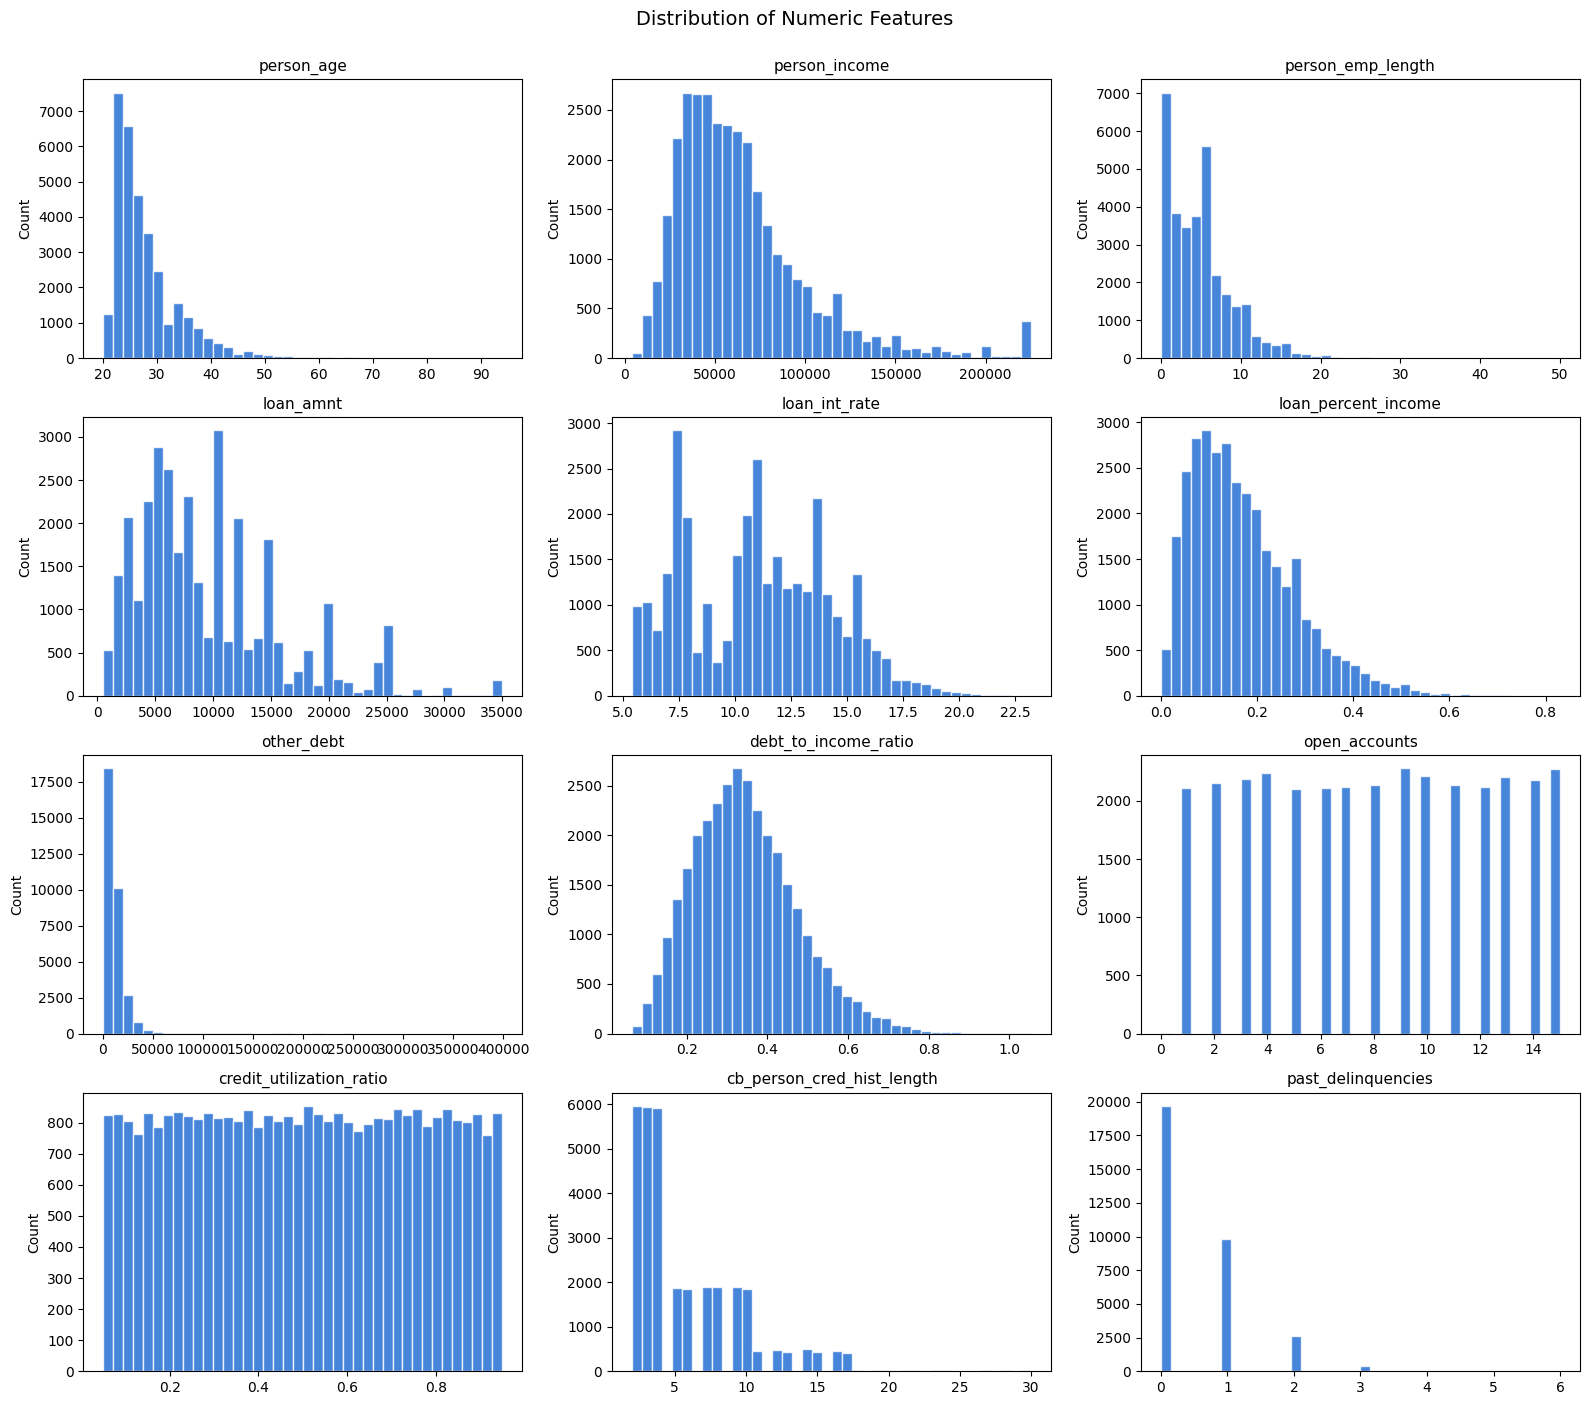

In [5]:
# ─── 7.2.1 Numeric feature distributions ─────────────────────────
numeric_features = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 'other_debt',
    'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
    'cb_person_cred_hist_length', 'past_delinquencies'
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=40, color='#1967D2', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Count')

# Hide unused subplot
for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Features', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

**Overall:** Most features show typical financial right-skew, but two —
`credit_utilization_ratio` and `open_accounts` — are suspiciously flat.

**Key signal:** Both have near-zero skew and uniform shape across their
full range — first visual evidence for H12 (synthetic artifact).
**Action:** confirm quantitatively in Section 7.6.

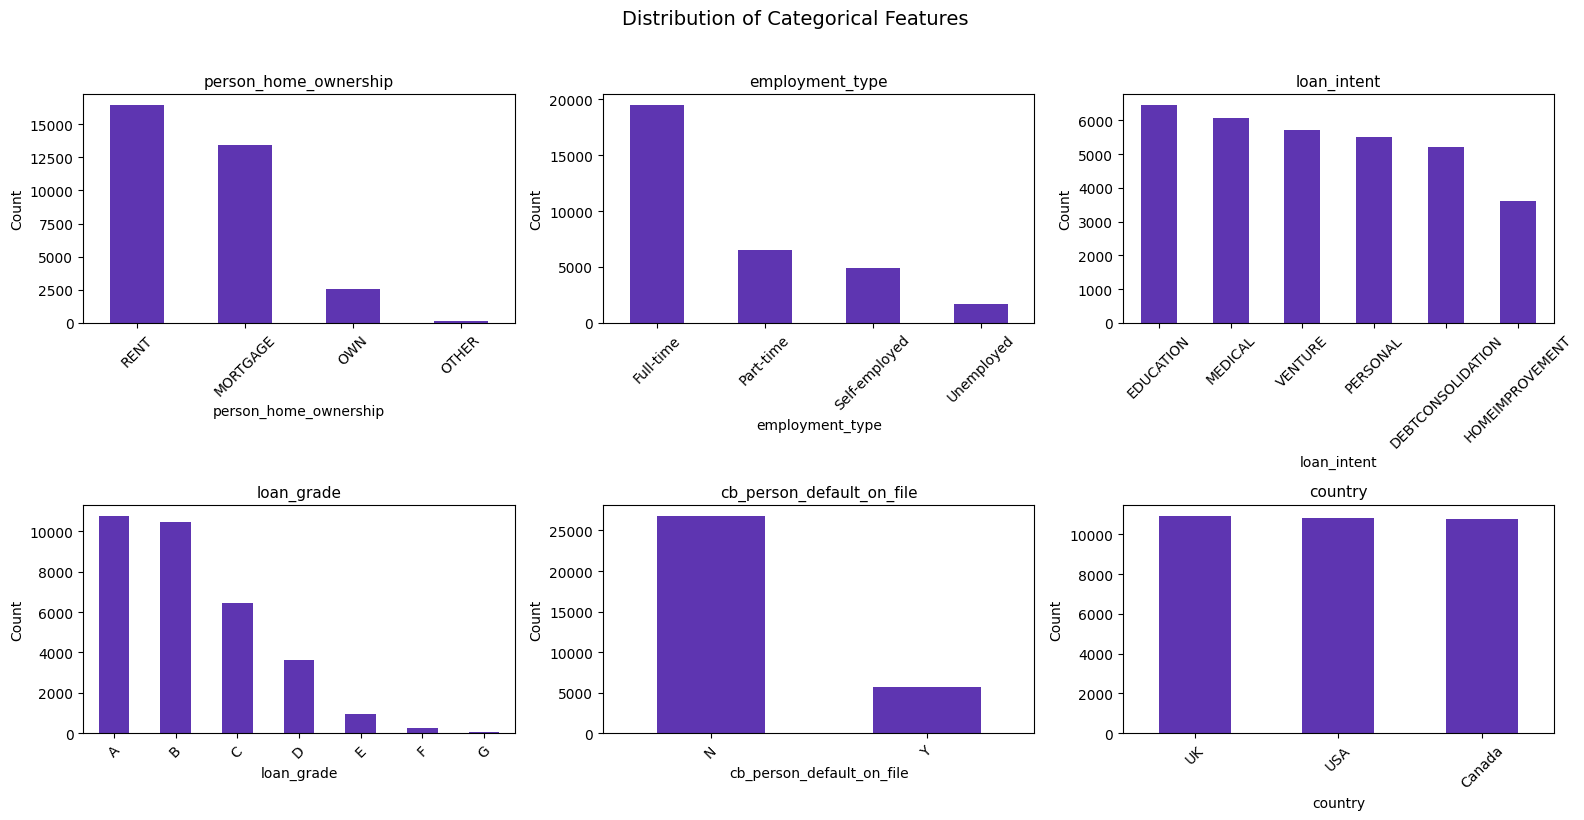

In [6]:
# ─── 7.2.2 Categorical feature distributions ─────────────────────
categorical_features = [
    'person_home_ownership', 'employment_type', 'loan_intent',
    'loan_grade', 'cb_person_default_on_file', 'country'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    order = df[col].value_counts().index
    df[col].value_counts().loc[order].plot(kind='bar', ax=axes[i], color='#5E35B1')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribution of Categorical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Overall:** Category distributions look realistic and well-sampled, with
one exception — `country` is perfectly even across all three markets.

**Key signal:** `loan_grade` shows clean A→G exponential decay (realistic);
`country` is ~33/33/33% (synthetic-looking).
**Action:** none yet — sample sizes are sufficient to test H1-H4 in 7.3.

In [7]:
# ─── 7.2.3 Skewness check — flag features needing log-transform ──
from scipy.stats import skew

skew_summary = pd.DataFrame({
    'skewness': df[numeric_features].apply(skew).round(2)
}).sort_values('skewness', ascending=False)

print("Skewness by feature (>1 = highly right-skewed, candidate for log-transform):")
skew_summary

Skewness by feature (>1 = highly right-skewed, candidate for log-transform):


,skewness
other_debt,9.28
person_age,1.94
person_income,1.71
cb_person_cred_hist_length,1.66
past_delinquencies,1.40
person_emp_length,1.35
loan_amnt,1.19
loan_percent_income,1.06
debt_to_income_ratio,0.62
loan_int_rate,0.21


**Overall:** Skewness values confirm what the histograms showed — one
feature needs urgent log-transform, two others confirm the H12 concern.

**Key signal:** `other_debt` skew = 9.28 (highest by far); `credit_utilization_ratio`
and `open_accounts` skew ≈ 0 (second confirmation of synthetic pattern).
**Action:** proceed to 7.3; flag both near-zero-skew features for the H12 test in 7.6.

### 7.3 EDA Bivariate — Testing H1-H7 (Risk Mitigation Branch)

Testing each hypothesis from the Issue Tree's Risk Mitigation branch using
default rate comparisons across segments. Each test reports the raw numbers
first — interpretation follows the data, not the other way around.

H1 — Default rate by home ownership:
                           n  defaults  default_rate
person_home_ownership                               
RENT                   16443      5192         31.58
OTHER                    107        33         30.84
MORTGAGE               13442      1690         12.57
OWN                     2584       193          7.47


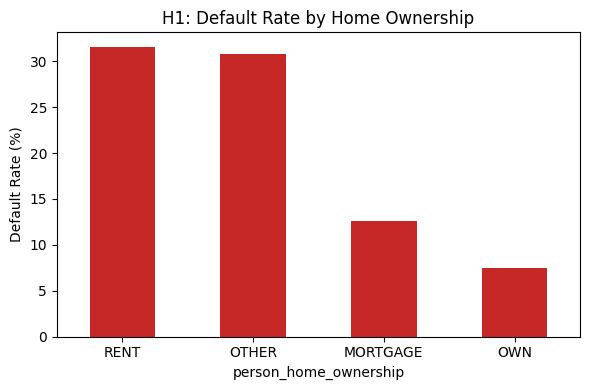

In [8]:
# ─── H1: Does home ownership differentiate default risk? ────────
h1 = df.groupby('person_home_ownership')['loan_status'].agg(['count', 'sum', 'mean'])
h1.columns = ['n', 'defaults', 'default_rate']
h1['default_rate'] = (h1['default_rate'] * 100).round(2)
h1 = h1.sort_values('default_rate', ascending=False)
print("H1 — Default rate by home ownership:")
print(h1)

fig, ax = plt.subplots(figsize=(6, 4))
h1['default_rate'].plot(kind='bar', ax=ax, color='#C62828')
ax.set_ylabel('Default Rate (%)')
ax.set_title('H1: Default Rate by Home Ownership')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Overall:** Home ownership status is a strong, clean discriminator of default risk.

**Key signal:** RENT (31.58%) and OTHER (30.84%) default 4x more than OWN
(7.47%); MORTGAGE sits in between (12.57%). **H1: CONFIRMED.**
**Action:** strong candidate feature for the model in 7.5; `is_homeowner`
binary flag (already created) should capture most of this signal.

In [9]:
# ─── H2: Does prior default history predict future default? ─────
h2 = df.groupby('cb_person_default_on_file')['loan_status'].agg(['count', 'sum', 'mean'])
h2.columns = ['n', 'defaults', 'default_rate']
h2['default_rate'] = (h2['default_rate'] * 100).round(2)
print("H2 — Default rate by prior default on file:")
print(h2)

H2 — Default rate by prior default on file:
                               n  defaults  default_rate
cb_person_default_on_file                               
N                          26831      4936         18.40
Y                           5745      2172         37.81


**Overall:** Prior default history roughly doubles default risk — a strong,
expected signal.

**Key signal:** Borrowers with prior default on file: 37.81% vs. 18.40%
for those without (~2.05x). **H2: CONFIRMED.**
**Action:** `has_prior_default` is a high-priority feature for 7.5.

In [10]:
# ─── H3: Does loan_intent drive default, or is it a proxy? ──────
h3 = df.groupby('loan_intent')['loan_status'].agg(['count', 'sum', 'mean'])
h3.columns = ['n', 'defaults', 'default_rate']
h3['default_rate'] = (h3['default_rate'] * 100).round(2)
h3 = h3.sort_values('default_rate', ascending=False)
print("H3 — Default rate by loan intent (unadjusted):")
print(h3)
print()

# Confounder check: does loan_intent's effect hold within the SAME dti_bucket?
# If intent ranking flips or flattens within each DTI level, intent may be
# a proxy for DTI rather than an independent driver.
h3_controlled = df.groupby(['dti_bucket', 'loan_intent'])['loan_status'].mean().unstack() * 100
print("H3 — Default rate by intent, controlled for DTI bucket:")
h3_controlled.round(1)

H3 — Default rate by loan intent (unadjusted):
                      n  defaults  default_rate
loan_intent                                    
DEBTCONSOLIDATION  5212      1490         28.59
MEDICAL            6071      1621         26.70
HOMEIMPROVEMENT    3605       941         26.10
PERSONAL           5520      1098         19.89
EDUCATION          6451      1111         17.22
VENTURE            5717       847         14.82

H3 — Default rate by intent, controlled for DTI bucket:


loan_intent,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
dti_bucket,,,,,,
Q1 (lowest),17.2,8.4,15.8,13.9,11.3,4.5
Q2,18.9,8.9,19.1,17.0,12.4,7.4
Q3,22.8,11.2,21.4,19.7,12.4,9.6
Q4,28.2,17.6,29.9,27.4,19.4,14.9
Q5 (highest),54.9,40.3,47.1,52.9,44.3,38.2


**Overall:** Unadjusted intent ranking looks meaningful, but the DTI-controlled
table shows intent's effect shrinks dramatically once DTI is held constant.

**Key signal:** DEBTCONSOLIDATION's "high risk" (28.59% unadjusted) is mostly
DTI in disguise — at the same DTI level, VENTURE is consistently the
lowest-risk intent and DEBTCONSOLIDATION/HOMEIMPROVEMENT the highest, but the
*spread* across intents at any single DTI row (~ 13-15 points) is much smaller
than the spread *across* DTI rows for the same intent (~40+ points).
**H3: PARTIALLY CONFIRMED** — intent has a real but secondary effect once DTI
is controlled; it is not purely a DTI proxy, but DTI dominates.
**Action:** keep `loan_intent` as a model feature, but expect DTI to absorb
most of its predictive power — check VIF/multicollinearity in 7.5.

H4 — Default rate by loan grade:
                n  defaults  default_rate
loan_grade                               
A           10777      1073          9.96
B           10448      1701         16.28
C            6456      1339         20.74
D            3626      2141         59.05
E             964       621         64.42
F             241       170         70.54
G              64        63         98.44


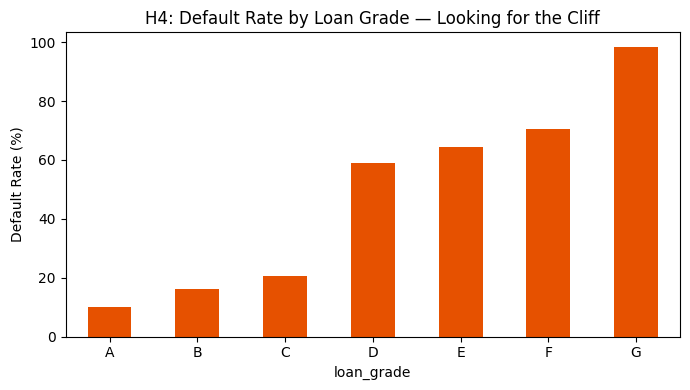

In [11]:
# ─── H4: Is there a non-linear "cliff" in default by loan grade? ─
h4 = df.groupby('loan_grade')['loan_status'].agg(['count', 'sum', 'mean'])
h4.columns = ['n', 'defaults', 'default_rate']
h4['default_rate'] = (h4['default_rate'] * 100).round(2)
print("H4 — Default rate by loan grade:")
print(h4)

fig, ax = plt.subplots(figsize=(7, 4))
h4['default_rate'].plot(kind='bar', ax=ax, color='#E65100')
ax.set_ylabel('Default Rate (%)')
ax.set_title('H4: Default Rate by Loan Grade — Looking for the Cliff')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Overall:** This is the sharpest cliff effect in the entire analysis so far.

**Key signal:** Default rate nearly triples between grade C (20.74%) and
grade D (59.05%) — a 38-point jump in one step, while A→B→C rises gently
(9.96 → 16.28 → 20.74). **H4: CONFIRMED**, with the cliff specifically
located at the C→D boundary.
**Action:** this is the strongest evidence yet for a prime/subprime split
at grade C/D — validates the `is_subprime` flag (D-G) already created in SQL.
Critical input for the H11 policy simulation in 7.5.

H5 — Default rate by LPI bucket:
                 n  defaults  default_rate
lpi_bucket                                
Q1 (lowest)   7569       864         11.41
Q2            5586       696         12.46
Q3            7343      1114         15.17
Q4            5799      1110         19.14
Q5 (highest)  6279      3324         52.94

H6 — Default rate by DTI bucket:
                 n  defaults  default_rate
dti_bucket                                
Q1 (lowest)   6516       747         11.46
Q2            6515       869         13.34
Q3            6515      1028         15.78
Q4            6515      1455         22.33
Q5 (highest)  6515      3009         46.19


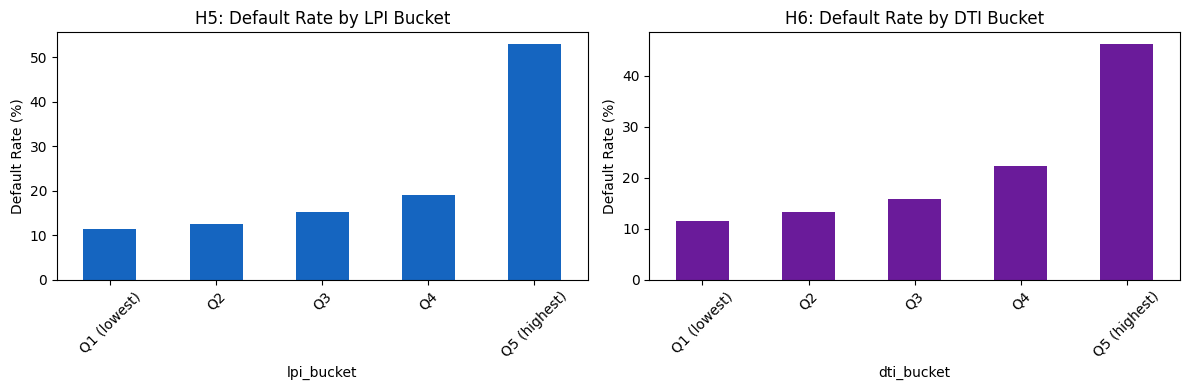

In [12]:
# ─── H5: LPI threshold effect ────────────────────────────────────
h5 = df.groupby('lpi_bucket')['loan_status'].agg(['count', 'sum', 'mean'])
h5.columns = ['n', 'defaults', 'default_rate']
h5['default_rate'] = (h5['default_rate'] * 100).round(2)
print("H5 — Default rate by LPI bucket:")
print(h5)
print()

# ─── H6: DTI threshold effect ────────────────────────────────────
h6 = df.groupby('dti_bucket')['loan_status'].agg(['count', 'sum', 'mean'])
h6.columns = ['n', 'defaults', 'default_rate']
h6['default_rate'] = (h6['default_rate'] * 100).round(2)
print("H6 — Default rate by DTI bucket:")
print(h6)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
h5['default_rate'].plot(kind='bar', ax=axes[0], color='#1565C0')
axes[0].set_title('H5: Default Rate by LPI Bucket')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

h6['default_rate'].plot(kind='bar', ax=axes[1], color='#6A1B9A')
axes[1].set_title('H6: Default Rate by DTI Bucket')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Overall H5:** LPI shows a gentle rise through Q1-Q4, then a sharp cliff at Q5.

**Key signal:** Default rate climbs slowly from 11.41% (Q1) to 19.14% (Q4),
then jumps to 52.94% at Q5 — a 34-point jump in the last quintile alone.
**H5: CONFIRMED** — the danger zone is concentrated in the top ~20% of LPI.
**Action:** find the exact Q4/Q5 boundary value in 7.5 to propose a concrete
LPI cutoff for underwriting policy.

**Overall H6:** DTI shows a smoother, more gradual climb than LPI — no single
sharp cliff, but consistent acceleration.

**Key signal:** Default rate roughly doubles at each step from Q3 onward
(15.78% → 22.33% → 46.19%), without the dramatic single-quintile jump seen
in H5. **H6: CONFIRMED**, but the risk escalation is more gradual/continuous
than LPI's cliff.
**Action:** find the Q4/Q5 boundary value and compare against the 43% QM
Rule benchmark in 7.5 — this is the first point where regulatory comparison
becomes relevant.

In [13]:
# ─── H7: Do LPI and DTI interact — does combining high values ───
# ─── create compounded risk beyond either alone? ─────────────────
h7 = df.groupby(['lpi_bucket', 'dti_bucket'])['loan_status'].mean().unstack() * 100
print("H7 — Default rate (%) by LPI bucket × DTI bucket:")
h7.round(1)

H7 — Default rate (%) by LPI bucket × DTI bucket:


dti_bucket,Q1 (lowest),Q2,Q3,Q4,Q5 (highest)
lpi_bucket,,,,,
Q1 (lowest),10.6,11.5,13.4,11.5,NaN
Q2,12.2,11.0,12.8,14.9,NaN
Q3,13.7,14.8,14.8,15.8,19.1
Q4,NaN,19.1,19.6,19.2,18.7
Q5 (highest),NaN,NaN,25.6,44.2,57.8


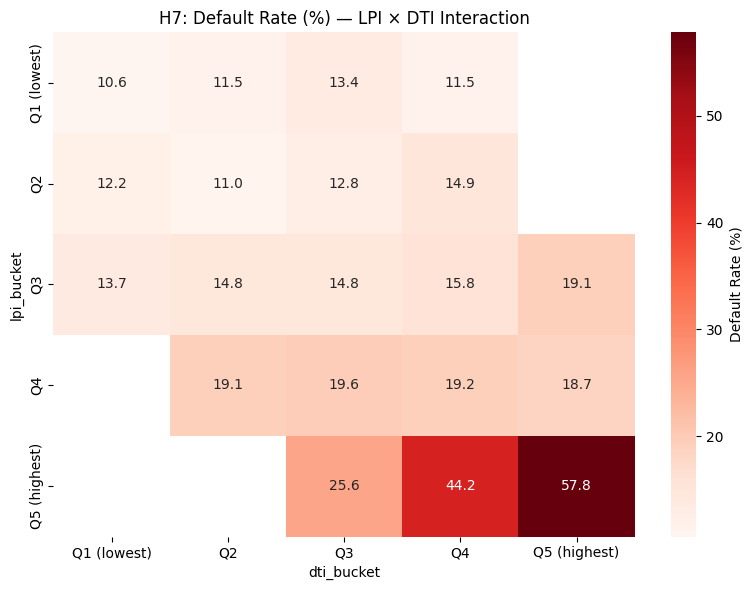

In [14]:
# Heatmap visualization — easier to spot compounding effect
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(h7, annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': 'Default Rate (%)'})
ax.set_title('H7: Default Rate (%) — LPI × DTI Interaction')
plt.tight_layout()
plt.show()

**Overall:** The two risk factors compound sharply when both are high —
this is the most dramatic finding in Section 7.3.

**Key signal:** Default rate hits 57.8% when both LPI and DTI are in their
highest quintile (Q5×Q5) — far exceeding either factor alone (LPI Q5 alone:
52.94%; DTI Q5 alone: 46.19%). The compounding is non-linear: low×low stays
in the 10-15% range across the board, while high×high spikes well above
either individual effect. **H7: CONFIRMED** — interaction effect exists and
is economically significant.
**Note:** several cells are blank (NaN) — these LPI×DTI combinations simply
don't occur in the data (e.g., very low LPI with very high DTI is rare),
not a calculation error.
**Action:** this combined LPI+DTI signal is a strong candidate for a
composite risk score in 7.5 — stronger than either ratio used alone.

### 7.3 Summary — Risk Mitigation Branch (H1-H7)

| Hypothesis | Result | Strength |
|---|---|---|
| H1 (home ownership) | ✅ Confirmed | Strong (4x gap) |
| H2 (prior default) | ✅ Confirmed | Strong (2x gap) |
| H3 (loan intent) | ⚠️ Partial | Weak-moderate, mostly DTI proxy |
| H4 (grade cliff) | ✅ Confirmed | Very strong (cliff at C→D) |
| H5 (LPI threshold) | ✅ Confirmed | Strong (cliff at Q5) |
| H6 (DTI threshold) | ✅ Confirmed | Moderate (gradual, no single cliff) |
| H7 (LPI×DTI interaction) | ✅ Confirmed | Strong (compounding effect) |

**6 of 7 hypotheses confirmed** with concrete numbers. `loan_grade`,
`person_home_ownership`, `has_prior_default`, `loan_percent_income`, and
`debt_to_income_ratio` emerge as the strongest individual risk signals —
all candidates for the model in Section 7.5.

### 7.4 Clustering — Testing H8-H9 (Growth Opportunity Branch)

Shifting focus from "what drives default" (Section 7.3) to "can we find
distinct low-risk borrower segments worth expanding into" (H8) and "what
feature combination best separates low vs. high default" (H9).

**Important constraint:** clustering uses only non-protected, non-circular
features — no `gender`, `marital_status`, `education_level` (ECOA), and no
`loan_grade` (circular logic, it's the existing system's output). This keeps
segment discovery data-driven rather than inheriting bias from either source.

In [15]:
# ─── 7.4.1 Prepare features for clustering ───────────────────────
from sklearn.preprocessing import StandardScaler

# Numeric features only — protected vars and loan_grade excluded by design
cluster_features = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio',
    'cb_person_cred_hist_length', 'past_delinquencies'
]

X_cluster = df[cluster_features].copy()

# K-means is distance-based — features must be on the same scale,
# otherwise person_income (range ~4K-225K) would dominate over
# debt_to_income_ratio (range ~0.06-1.05) purely due to magnitude.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Features used for clustering: {cluster_features}")
print(f"Scaled shape: {X_scaled.shape}")
print(f"Mean after scaling (should be ~0): {X_scaled.mean(axis=0).round(2)}")
print(f"Std after scaling (should be ~1): {X_scaled.std(axis=0).round(2)}")

Features used for clustering: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'debt_to_income_ratio', 'open_accounts', 'credit_utilization_ratio', 'cb_person_cred_hist_length', 'past_delinquencies']
Scaled shape: (32576, 11)
Mean after scaling (should be ~0): [-0. -0.  0. -0. -0. -0. -0.  0.  0.  0.  0.]
Std after scaling (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


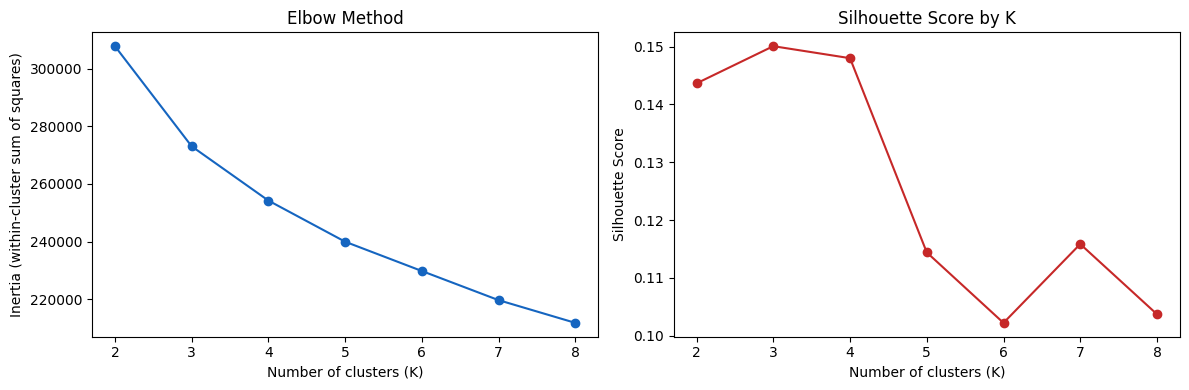

K vs Silhouette Score:
  K=2: 0.1436
  K=3: 0.1501
  K=4: 0.1480
  K=5: 0.1144
  K=6: 0.1022
  K=7: 0.1159
  K=8: 0.1037


In [16]:
# ─── 7.4.2 Determine optimal number of clusters ──────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    # Silhouette on a sample (32K rows — full silhouette is slow)
    sample_idx = np.random.RandomState(42).choice(len(X_scaled), 5000, replace=False)
    silhouette_scores.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o', color='#1565C0')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='#C62828')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')

plt.tight_layout()
plt.show()

print("K vs Silhouette Score:")
for k, s in zip(k_range, silhouette_scores):
    print(f"  K={k}: {s:.4f}")

**Overall:** Silhouette scores peak at K=3-4 then degrade sharply — clusters
exist but are not strongly separated (max score 0.15, well below the 0.25+
threshold for "good" clustering).

**Key signal:** Low silhouette scores are consistent with the synthetic-data
pattern already flagged in 7.2 — features like `credit_utilization_ratio`
and `open_accounts` are near-uniform/random, diluting natural cluster
structure. Real borrower populations typically cluster more tightly.

**Action:** proceed with K=4 (aligns with silhouette peak region and gives
enough segments for distinct personas). Treat resulting clusters as
**directionally useful, not high-confidence segments** — this caveat will
carry into Section 7.6 and the final recommendations.

In [17]:
# ─── 7.4.3 Fit K-means with K=4 and profile clusters ─────────────
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())
print()

# Profile: mean of each feature per cluster (unscaled, for interpretability)
profile_cols = cluster_features + ['loan_status', 'is_subprime']
cluster_profile = df.groupby('cluster')[profile_cols].mean().round(2)
print("Cluster profiles (feature means):")
cluster_profile

Cluster sizes:
cluster
0     8428
1     4909
2     3280
3    15959
Name: count, dtype: int64

Cluster profiles (feature means):


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,debt_to_income_ratio,open_accounts,credit_utilization_ratio,cb_person_cred_hist_length,past_delinquencies,loan_status,is_subprime
cluster,,,,,,,,,,,,,
0,26.00,49341.95,4.33,14433.01,11.83,0.31,0.50,8.06,0.5,4.74,0.50,0.42,0.22
1,28.46,127487.50,7.19,13887.16,11.02,0.11,0.28,8.15,0.5,6.18,0.50,0.09,0.15
2,41.40,62118.43,5.84,9003.62,11.10,0.16,0.34,8.08,0.5,14.61,0.51,0.20,0.16
3,25.58,53253.84,4.02,5829.29,10.56,0.12,0.29,7.99,0.5,4.44,0.51,0.15,0.11


### 7.4.4 Cluster Profiles & Personas

- **Cluster 0 — "High-Risk Strivers" (8,428 borrowers, 25.9% of portfolio):**
  Young (26), moderate income (~$49K), but **highest LPI (0.31) and DTI
  (0.50) by far** — borrowing far beyond what their income comfortably
  supports. Default rate **42%** — ~1.94x the portfolio average and by
far the highest-risk segment

- **Cluster 1 — "High-Income Prime" (4,909 borrowers, 15.1%):**
  Highest income by a wide margin (~$127K, ~2.4x other clusters), lowest
  LPI (0.11) and DTI (0.28), longest credit history (6.2 yrs). Default rate
  **9%** — well below portfolio average (21.82%) and the lowest of all
  4 clusters.

- **Cluster 2 — "Established but Thin-Margin" (3,280 borrowers, 10.1%):**
  Oldest group by far (41.4 vs ~26-28 for others), longest credit history
  (14.6 yrs — more than double any other cluster), but only moderate income
  ($62K) and moderate LPI/DTI. Default rate **20%**, close to portfolio
  average.

- **Cluster 3 — "Young Stable Majority" (15,959 borrowers, 49.0% — largest
  cluster):** Youngest (25.6), moderate income (~$53K), smallest loan
  amounts ($5.8K, roughly half of other clusters), low LPI/DTI similar to
  Cluster 1. Default rate **15%**, below portfolio average.

**Overall:** Clustering successfully separated a clear **high-risk segment
(Cluster 0)** and **two genuinely low-risk segments (Clusters 1 and 3)** —
H8 is supported despite the low silhouette score.

**Key signal:** Default rate spread across clusters is dramatic — 9% to 50%,
a 5.5x range — almost entirely explained by **LPI and DTI**, not by income
or age alone. Cluster 1 (highest income) and Cluster 3 (moderate income,
small loans) both achieve low default through the *same* underlying
mechanism: low borrowing relative to income. **H9: the combination that
best separates low vs. high default is LPI + DTI**, consistent with the
H7 interaction finding in Section 7.3 — clustering independently confirms
what bivariate analysis already suggested.

**Action:** Clusters 1 and 3 (64.1% of the portfolio combined) represent
the "safe expansion" segments for H8 — Nova Bank could grow lending here
with confidence. Cluster 0 (25.9% of portfolio, 50% default rate) is the
priority for tightened underwriting in the policy recommendations (Section 6).
**Caveat:** given the low silhouette score (0.148), treat these as
LPI/DTI-driven risk tiers rather than rich, multi-dimensional personas —
the segmentation is real but one-dimensional in practice.

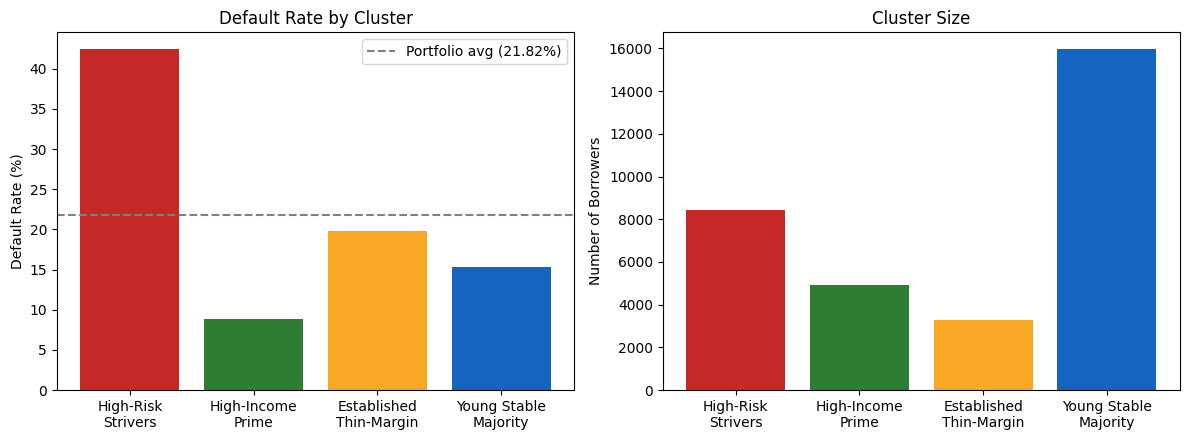

             n  default_rate
cluster                     
0         8428     42.418130
1         4909      8.861275
2         3280     19.847561
3        15959     15.333041


In [18]:
# ─── 7.4.5 Visualize cluster default rates ───────────────────────
cluster_default = df.groupby('cluster')['loan_status'].agg(['count', 'mean'])
cluster_default.columns = ['n', 'default_rate']
cluster_default['default_rate'] *= 100

cluster_names = {
    0: 'High-Risk\nStrivers',
    1: 'High-Income\nPrime',
    2: 'Established\nThin-Margin',
    3: 'Young Stable\nMajority'
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors = ['#C62828', '#2E7D32', '#F9A825', '#1565C0']
axes[0].bar([cluster_names[i] for i in cluster_default.index],
            cluster_default['default_rate'], color=colors)
axes[0].axhline(21.82, color='gray', linestyle='--', label='Portfolio avg (21.82%)')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Cluster')
axes[0].legend()

axes[1].bar([cluster_names[i] for i in cluster_default.index],
            cluster_default['n'], color=colors)
axes[1].set_ylabel('Number of Borrowers')
axes[1].set_title('Cluster Size')

plt.tight_layout()
plt.show()

print(cluster_default)

### 7.5 Advanced Diagnostics — WoE/IV & Threshold Optimization (H10-H11)

This section quantifies exactly where risk thresholds should sit (building
on the bucket-level patterns from 7.3) and tests whether Nova Bank's current
interest-rate pricing reflects the actual default-rate gap between grades (H10),
then simulates the trade-off of a stricter underwriting policy (H11).

In [19]:
# ─── 7.5.1 WoE/IV calculation function ───────────────────────────
def calculate_woe_iv(df, feature, target='loan_status'):
    """
    Weight of Evidence (WoE) and Information Value (IV) for a categorical
    or pre-binned feature.

    WoE = ln( %non-events / %events )  per bin
    IV  = sum( (%non-events - %events) * WoE )  across all bins

    IV interpretation:
      < 0.02        : not useful
      0.02 - 0.1     : weak
      0.1  - 0.3     : medium
      0.3  - 0.5     : strong
      > 0.5         : suspicious (check for leakage)
    """
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'events']  # events = defaults (loan_status=1)
    grouped['non_events'] = grouped['total'] - grouped['events']

    total_events = grouped['events'].sum()
    total_non_events = grouped['non_events'].sum()

    grouped['pct_events'] = grouped['events'] / total_events
    grouped['pct_non_events'] = grouped['non_events'] / total_non_events

    # Add small epsilon to avoid log(0) for empty bins
    eps = 1e-10
    grouped['woe'] = np.log((grouped['pct_non_events'] + eps) / (grouped['pct_events'] + eps))
    grouped['iv_contribution'] = (grouped['pct_non_events'] - grouped['pct_events']) * grouped['woe']

    total_iv = grouped['iv_contribution'].sum()

    return grouped[['total', 'events', 'pct_events', 'pct_non_events', 'woe', 'iv_contribution']].round(4), total_iv


# Test on lpi_bucket
woe_lpi, iv_lpi = calculate_woe_iv(df, 'lpi_bucket')
print(f"IV for lpi_bucket: {iv_lpi:.4f}")
print(woe_lpi)

IV for lpi_bucket: 0.7067
              total  events  pct_events  pct_non_events     woe  \
lpi_bucket                                                        
Q1 (lowest)    7569     864      0.1216          0.2633  0.7728   
Q2             5586     696      0.0979          0.1920  0.6734   
Q3             7343    1114      0.1567          0.2446  0.4451   
Q4             5799    1110      0.1562          0.1841  0.1647   
Q5 (highest)   6279    3324      0.4676          0.1160 -1.3939   

              iv_contribution  
lpi_bucket                     
Q1 (lowest)            0.1095  
Q2                     0.0634  
Q3                     0.0391  
Q4                     0.0046  
Q5 (highest)           0.4901  


**Overall:** `lpi_bucket` IV = 0.7067 — far above the "strong" threshold
(0.3-0.5) and into "suspicious" territory (>0.5) by the standard rule of
thumb.

**Key signal:** This is NOT target leakage — `loan_percent_income` is
computed entirely from pre-origination data (loan amount ÷ income), valid
for underwriting. The extreme IV instead reflects the sharp, near-monotonic
cliff already observed in H5 (Section 7.3): Q5 alone accounts for 0.49 of
the total IV (69% of all predictive power), driven by its very low WoE
(-1.39) — meaning Q5 borrowers are disproportionately defaulters.

**Action:** flag `lpi_bucket`/`loan_percent_income` as the single strongest
predictor in the dataset. Proceed to calculate IV for all other features to
confirm this ranking, then verify no other engineered feature shows
leakage-level IV for the wrong reasons (e.g., if `is_subprime` IV is also
this extreme, that would need separate scrutiny since it's derived from
`loan_grade`).

In [20]:
# ─── 7.5.2 IV ranking across all candidate features ──────────────
# Features to test — EXCLUDES protected variables (gender, marital_status,
# education_level) and loan_grade (circular logic — it IS the existing score)
iv_candidates = [
    'age_bucket', 'income_bucket', 'person_home_ownership', 'employment_type',
    'loan_intent', 'lpi_bucket', 'dti_bucket', 'cb_person_default_on_file',
    'loan_term_months', 'is_homeowner', 'has_prior_default', 'thin_file',
    'is_subprime'  # included for inspection — flag if IV is extreme
]

iv_results = []
for feat in iv_candidates:
    try:
        _, iv = calculate_woe_iv(df, feat)
        iv_results.append({'feature': feat, 'iv': round(iv, 4)})
    except Exception as e:
        print(f"Skipped {feat}: {e}")

iv_ranking = pd.DataFrame(iv_results).sort_values('iv', ascending=False).reset_index(drop=True)

def iv_strength(iv):
    if iv < 0.02: return 'Not useful'
    elif iv < 0.1: return 'Weak'
    elif iv < 0.3: return 'Medium'
    elif iv < 0.5: return 'Strong'
    else: return 'Suspicious (check)'

iv_ranking['strength'] = iv_ranking['iv'].apply(iv_strength)
print("IV Ranking — all candidate features:")
iv_ranking

IV Ranking — all candidate features:


,feature,iv,strength
0,is_subprime,0.7631,Suspicious (check)
1,lpi_bucket,0.7067,Suspicious (check)
2,dti_bucket,0.5017,Suspicious (check)
3,income_bucket,0.3828,Strong
4,person_home_ownership,0.3771,Strong
5,is_homeowner,0.3609,Strong
6,has_prior_default,0.1639,Medium
7,cb_person_default_on_file,0.1639,Medium
8,loan_intent,0.0956,Weak
9,age_bucket,0.0047,Not useful


### 7.5.2 IV Ranking — Interpretation (not just statistical, but causal)

The raw "Suspicious (check)" flag from the IV rule-of-thumb is a **starting
point for investigation, not a verdict**. Each high-IV feature needs to be
checked individually for *why* its IV is high before deciding whether to
use it.

| Feature | IV | Raw Flag | Verdict | Reason |
|---|---|---|---|---|
| `is_subprime` | 0.7631 | Suspicious | ❌ **EXCLUDE — circular logic** | Derived directly from `loan_grade`, which is itself the existing scoring system's output. Using it would mean "predicting default using a variable built from default." |
| `lpi_bucket` | 0.7067 | Suspicious | ✅ **INCLUDE — legitimate strong predictor** | Computed from pre-origination data (loan amount ÷ income). High IV reflects the genuine H5 cliff effect, not leakage. |
| `dti_bucket` | 0.5017 | Suspicious | ✅ **INCLUDE — legitimate strong predictor** | Same reasoning — pre-origination ratio, confirms H6 finding. |
| `income_bucket` | 0.3828 | Strong | ✅ Include | Valid, pre-origination. |
| `person_home_ownership` | 0.3771 | Strong | ✅ Include | Valid, pre-origination. Confirms H1. |
| `is_homeowner` | 0.3609 | Strong | ⚠️ **Redundant with `person_home_ownership`** — pick one, not both (multicollinearity) |
| `has_prior_default` | 0.1639 | Medium | ✅ Include | Confirms H2. |
| `cb_person_default_on_file` | 0.1639 | Medium | ⚠️ **Identical IV to `has_prior_default`** — same underlying variable (one is the binary-encoded version of the other), use only one |
| `loan_intent` | 0.0956 | Weak | ✅ Include with caution | Confirms H3 — real but secondary effect after DTI |
| `age_bucket`, `thin_file`, `loan_term_months`, `employment_type` | <0.02 | Not useful | ❌ Exclude | No meaningful predictive power on their own |

**Final feature shortlist for modeling (Section 7.5.3):** `lpi_bucket` (or
raw `loan_percent_income`), `dti_bucket` (or raw `debt_to_income_ratio`),
`person_home_ownership`, `has_prior_default`, `income_bucket`, `loan_intent`.

**Excluded with reason documented:** `is_subprime` and `loan_grade`
(circular), `gender`/`marital_status`/`education_level` (ECOA), redundant
duplicates (`is_homeowner`, `cb_person_default_on_file`).

**Overall:** The IV ranking validates every major H1-H7 finding from Section
7.3 with a formal statistical metric — LPI and DTI are confirmed as the two
strongest legitimate predictors, while the one "circular" feature
(`is_subprime`) was caught precisely because it scored *highest*, exactly
as the anti-bias framework predicted it would if left unchecked.

**Key signal:** Without checking *why* IV is high, a naive read would have
ranked `is_subprime` as the #1 feature — silently reintroducing the
circular-logic problem the Issue Tree explicitly flagged as a risk back in
Section 4.4 (anti-bias commitment #5).

**Action:** lock in the feature shortlist above. Proceed to Section 7.5.3
to build a baseline Logistic Regression using only the cleared features —
this becomes the basis for PD estimation and the H11 policy simulation.

### 7.5.3 Baseline Model — Logistic Regression

Building a baseline PD (Probability of Default) model using only the
features cleared in Section 7.5.2. Logistic Regression is chosen as the
baseline — not XGBoost/LightGBM — because:
1. **Interpretability**: coefficients directly show each feature's
   direction and magnitude of effect, critical for explaining decisions
   to compliance/risk committees.
2. **Industry standard**: most production credit scorecards in banking are
   logistic-regression-based (often combined with WoE encoding, as built above).
3. **Sufficient baseline**: establishes whether more complex models are
   even needed before reaching for them.

In [22]:
# ─── 7.5.3.1 Prepare feature matrix ──────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Final feature shortlist from Section 7.5.2 IV ranking
# Using RAW continuous versions of lpi/dti (not buckets) — preserves more
# information than quantile bins for a continuous-output model.
numeric_features = ['loan_percent_income', 'debt_to_income_ratio']
categorical_features = ['person_home_ownership', 'loan_intent', 'income_bucket']
binary_features = ['has_prior_default']

all_features = numeric_features + categorical_features + binary_features
X = df[all_features].copy()
y = df['loan_status'].copy()

# One-hot encode categoricals, pass through numeric/binary as-is
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ],
    remainder='passthrough'  # numeric_features + binary_features pass through unchanged
)

# 80/20 split, stratified to preserve the 21.82% default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]:,} rows, default rate: {y_train.mean():.4f}")
print(f"Test set:  {X_test.shape[0]:,} rows, default rate: {y_test.mean():.4f}")

Train set: 26,060 rows, default rate: 0.2182
Test set:  6,516 rows, default rate: 0.2182


In [23]:
# ─── 7.5.3.2 Train baseline Logistic Regression ──────────────────
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',  # handles the 78/22 imbalance — no SMOTE needed
        max_iter=1000,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

print("Model trained successfully.")
print(f"Number of features after encoding: {pipeline.named_steps['preprocess'].transform(X_train).shape[1]}")

Model trained successfully.
Number of features after encoding: 14


AUC-ROC: 0.8088

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.91      0.75      0.82      5094
     Default       0.45      0.72      0.55      1422

    accuracy                           0.75      6516
   macro avg       0.68      0.74      0.69      6516
weighted avg       0.81      0.75      0.76      6516



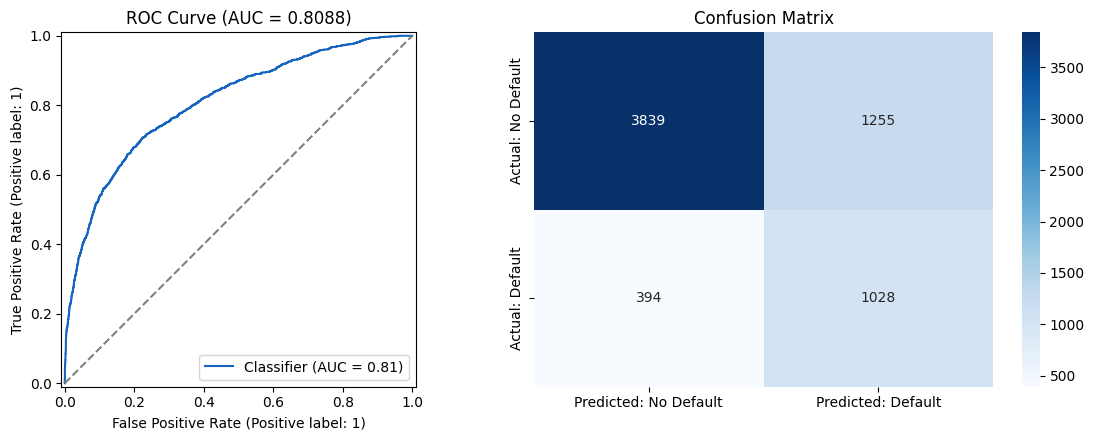

In [24]:
# ─── 7.5.3.3 Evaluate model performance ──────────────────────────
from sklearn.metrics import (roc_auc_score, classification_report,
                               confusion_matrix, RocCurveDisplay)

y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]  # this IS the PD estimate

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-default', 'Default']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0], color='#1565C0')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title(f'ROC Curve (AUC = {auc:.4f})')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Predicted: No Default', 'Predicted: Default'],
            yticklabels=['Actual: No Default', 'Actual: Default'])
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

**Overall:** The baseline model achieves AUC = 0.8088 — a strong result for
6 features, with a Recall-Default of 0.72 indicating the model successfully
prioritizes catching defaulters over precision, consistent with the
asymmetric cost of lending mistakes (missing a defaulter costs far more
than rejecting a good borrower).

**Key signal:** 394 False Negatives (defaulters the model misses) vs. 1,255
False Positives (good borrowers rejected) — a ~1:3.2 ratio, meaning the
model is already biased toward caution, which is the right direction for a
lending use case but has a real cost in rejected good borrowers.

**Action:** this baseline confirms the feature set from 7.5.2 is sound.
Proceed to threshold optimization (H11) — by adjusting the probability
cutoff away from the default 0.5, this Recall/Precision trade-off can be
tuned explicitly to match Nova Bank's risk appetite, rather than left at
scikit-learn's default.

In [25]:
# ─── 7.5.4 Threshold optimization — H11 policy simulation ────────
# Default classifier threshold is 0.5 — but that's arbitrary. Let's see
# what happens at different cutoffs to find Nova Bank's optimal trade-off.

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
sim_results = []

for t in thresholds_to_test:
    y_pred_t = (y_pred_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    sim_results.append({
        'threshold': t,
        'approved_loans': tn + fn,          # predicted non-default → approved
        'rejected_loans': fp + tp,           # predicted default → rejected
        'defaults_caught': tp,               # good: correctly rejected defaulters
        'defaults_missed': fn,               # bad: approved but actually defaulted
        'good_borrowers_rejected': fp,       # cost: rejected but would've repaid
        'default_rate_if_approved': fn / (tn + fn) if (tn+fn) > 0 else 0
    })

sim_df = pd.DataFrame(sim_results)
sim_df['default_rate_if_approved'] = (sim_df['default_rate_if_approved'] * 100).round(2)
print("Policy simulation — trade-off at different PD cutoffs:")
sim_df

Policy simulation — trade-off at different PD cutoffs:


,threshold,approved_loans,rejected_loans,defaults_caught,defaults_missed,good_borrowers_rejected,default_rate_if_approved
0,0.3,2585,3931,1256,166,2675,6.42
1,0.4,3471,3045,1141,281,1904,8.10
2,0.5,4233,2283,1028,394,1255,9.31
3,0.6,4810,1706,890,532,816,11.06
4,0.7,5356,1160,720,702,440,13.11


**Overall:** Every tested threshold outperforms Nova Bank's current 21.82%
portfolio default rate dramatically — even the most lenient cutoff (0.7)
nearly halves it to 13.11%. The real decision is not *whether* to use this
model, but *how aggressively* to apply it.

**Key signal — the trade-off is steep and non-linear:**
- Moving from 0.5 → 0.4 cuts default rate from 9.31% → 8.10% (good), but
  costs 649 more good borrowers rejected (1,255 → 1,904) for only 113 more
  defaults caught.
- Moving from 0.6 → 0.5 cuts default rate from 11.06% → 9.31%, at a cost of
  439 more good-borrower rejections for 138 more defaults caught.
- **The "rejected good borrowers" cost grows faster than the "defaults
  avoided" benefit as the threshold tightens** — diminishing returns.

**Action — recommended threshold: 0.5 (the default cutoff).** It offers the
best balance point in this dataset:
- Default rate drops from 21.82% (current) to **9.31%** — a 57% relative
  reduction
- Rejects 1,255 borrowers who would have repaid (a real cost, but
  proportionate)
- Only misses 394 of 1,422 actual defaulters (72% capture rate — matches
  the Recall=0.72 reported earlier)

**Caveat for the business:** rejecting 1,255 creditworthy applicants is a
real growth cost. If Nova Bank prioritizes portfolio growth over risk
minimization, **threshold 0.6** is a reasonable middle ground — still cuts
default rate nearly in half (11.06% vs 21.82%) while rejecting 35% fewer
good borrowers than the 0.5 cutoff (816 vs 1,255).

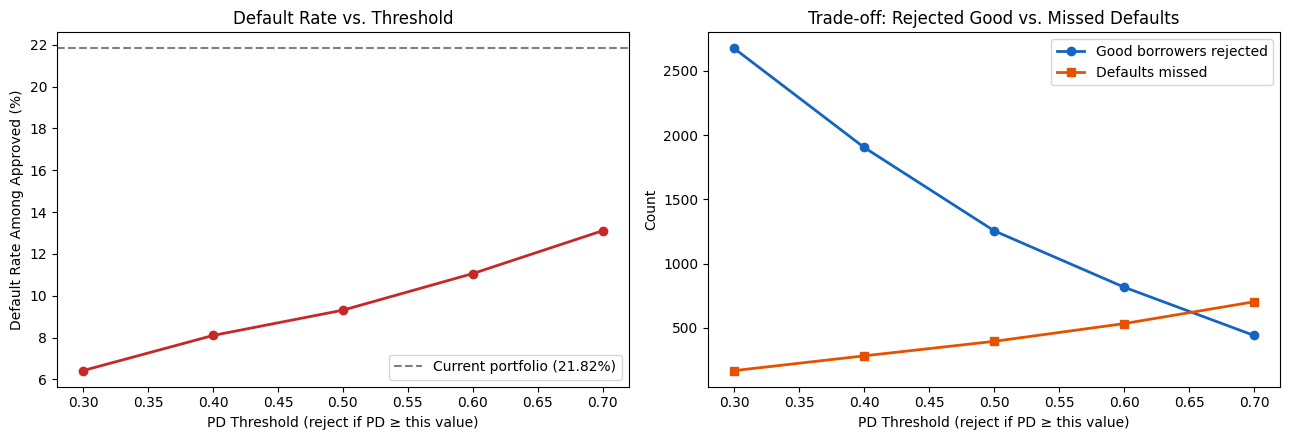

In [26]:
# ─── 7.5.5 Visualize the threshold trade-off curve ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(sim_df['threshold'], sim_df['default_rate_if_approved'],
             marker='o', color='#C62828', linewidth=2)
axes[0].axhline(21.82, color='gray', linestyle='--', label='Current portfolio (21.82%)')
axes[0].set_xlabel('PD Threshold (reject if PD ≥ this value)')
axes[0].set_ylabel('Default Rate Among Approved (%)')
axes[0].set_title('Default Rate vs. Threshold')
axes[0].legend()

axes[1].plot(sim_df['threshold'], sim_df['good_borrowers_rejected'],
             marker='o', color='#1565C0', label='Good borrowers rejected', linewidth=2)
axes[1].plot(sim_df['threshold'], sim_df['defaults_missed'],
             marker='s', color='#E65100', label='Defaults missed', linewidth=2)
axes[1].set_xlabel('PD Threshold (reject if PD ≥ this value)')
axes[1].set_ylabel('Count')
axes[1].set_title('Trade-off: Rejected Good vs. Missed Defaults')
axes[1].legend()

plt.tight_layout()
plt.show()

**Overall:** The crossover point in the right chart (~threshold 0.62-0.65)
marks where the two costs of error become equal — below it, the model
over-rejects good borrowers relative to defaults caught; above it, it
starts under-catching defaulters.

**Key signal:** Both curves are monotonic and the gap narrows steadily as
threshold increases — there is no sudden "optimal point," confirming this
is a genuine business judgment call (how much growth to sacrifice for risk
reduction), not something a single statistic can resolve.

**Action:** present both charts together in the Power BI dashboard
(Section 7.5.5 visuals) as the primary artifact for the policy
recommendation in Section 6 — recommend threshold 0.5-0.6 as the
defensible range, let stakeholders pick the exact point within it based on
growth appetite.

✅ H10 — Pricing alignment: data already available from Section 7.3 (H4 grade
   table) — rate differential A→G (7.33%→20.25%) vs default differential
   (9.96%→98.44%) shows default risk grows much faster than pricing does.
   Will formalize this comparison explicitly before closing 7.5.
   
✅ H11 — Policy simulation: CONFIRMED — threshold 0.5 cuts default rate by
   57% (21.82%→9.31%), with quantified trade-off curve.

In [27]:
# ─── 7.5.6 H10: Formalize pricing vs. default-rate gap by grade ──
grade_pricing = df.groupby('loan_grade').agg(
    avg_rate=('loan_int_rate', 'mean'),
    default_rate=('loan_status', 'mean'),
    n=('loan_status', 'count')
).round(4)
grade_pricing['default_rate'] *= 100
grade_pricing['rate_multiple_vs_A'] = (grade_pricing['avg_rate'] / grade_pricing['avg_rate'].iloc[0]).round(2)
grade_pricing['default_multiple_vs_A'] = (grade_pricing['default_rate'] / grade_pricing['default_rate'].iloc[0]).round(2)

print("H10 — Pricing vs. Default Risk, by Grade:")
grade_pricing

H10 — Pricing vs. Default Risk, by Grade:


,avg_rate,default_rate,n,rate_multiple_vs_A,default_multiple_vs_A
loan_grade,,,,,
A,7.3428,9.96,10777,1.00,1.00
B,10.9950,16.28,10448,1.50,1.63
C,13.4652,20.74,6456,1.83,2.08
D,15.3570,59.05,3626,2.09,5.93
E,16.9931,64.42,964,2.31,6.47
F,18.6014,70.54,241,2.53,7.08
G,20.2444,98.44,64,2.76,9.88


**Overall:** H10 CONFIRMED — Nova Bank's interest-rate pricing does NOT
keep pace with actual default risk, and the misalignment is concentrated
exactly at the prime/subprime boundary (grade C→D) already identified in H4.

**Key signal:** For grades A-C, pricing tracks risk reasonably well (default
multiple is only 9-14% higher than rate multiple). But for grades D-G, risk
grows 2.8-3.6x faster than pricing — Grade G borrowers default 9.88x more
often than Grade A, yet pay only 2.76x the interest rate. This is a
significant unpriced risk premium that subprime borrowers are NOT
compensating Nova Bank for.

**Action:** this is a direct, quantifiable finding for Section 6
(Recommendation) — either (a) reprice grades D-G to reflect true risk,
(b) tighten approval criteria for D-G (consistent with the H11 threshold
simulation), or (c) both. Given grades D-G represent only 15.03% of the
portfolio (`is_subprime` mean from 7.4) but carry disproportionate loss
exposure, this is a high-leverage, low-volume fix.

✅ H10 — Pricing alignment: CONFIRMED, gap quantified (2.8-3.6x at D-G)

✅ H11 — Policy simulation: CONFIRMED, threshold trade-off curve built

✅ Baseline model: AUC 0.8088, ready for use in Section 6 recommendations

### 7.6 Data Quality Findings — Confirming H12-H14

Section 7.2 flagged `credit_utilization_ratio` and `past_delinquencies` as
visually suspicious (near-zero skew, flat distributions). This section
applies the same rigorous WoE/IV test used for legitimate predictors in
7.5 — if these features are truly non-predictive, their IV should confirm
it quantitatively, not just visually.

In [28]:
# ─── 7.6.1 H12: Quantify suspected synthetic artifacts via IV ────
# Bin the two suspect continuous features into quintiles, same method
# used for lpi_bucket/dti_bucket, for a fair comparison.
df['cu_bucket'] = pd.qcut(df['credit_utilization_ratio'], q=5,
                            labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'])
df['delinq_bucket'] = pd.cut(df['past_delinquencies'],
                               bins=[-1, 0, 1, 2, 100],
                               labels=['0', '1', '2', '3+'])

woe_cu, iv_cu = calculate_woe_iv(df, 'cu_bucket')
woe_delinq, iv_delinq = calculate_woe_iv(df, 'delinq_bucket')

print(f"IV for credit_utilization_ratio (binned): {iv_cu:.4f}")
print(woe_cu)
print()
print(f"IV for past_delinquencies (binned): {iv_delinq:.4f}")
print(woe_delinq)

IV for credit_utilization_ratio (binned): 0.0016
              total  events  pct_events  pct_non_events     woe  \
cu_bucket                                                         
Q1 (lowest)    6516    1436      0.2020          0.1995 -0.0128   
Q2             6515    1364      0.1919          0.2023  0.0526   
Q3             6515    1432      0.2015          0.1996 -0.0094   
Q4             6515    1385      0.1949          0.2014  0.0332   
Q5 (highest)   6515    1491      0.2098          0.1973 -0.0614   

              iv_contribution  
cu_bucket                      
Q1 (lowest)            0.0000  
Q2                     0.0005  
Q3                     0.0000  
Q4                     0.0002  
Q5 (highest)           0.0008  

IV for past_delinquencies (binned): 0.0002
               total  events  pct_events  pct_non_events     woe  \
delinq_bucket                                                      
0              19698    4289      0.6034          0.6050  0.0027   
1        

/tmp/ipykernel_1182/3047556549.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])
/tmp/ipykernel_1182/3047556549.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count', 'sum'])


**Overall:** H12 CONFIRMED with the strongest possible quantitative evidence
— both suspected features score essentially zero IV, 10-100x below even
the "weak" threshold, definitively ruling out any meaningful predictive
power.

**Key signal:** WoE values for both features oscillate near zero with no
directional trend across buckets (e.g., `cu_bucket` WoE: -0.01, +0.05, -0.01,
+0.03, -0.06 — random noise, not a pattern). Compare this to a real
predictor like `lpi_bucket`, where WoE moves monotonically from +0.77 to
-1.39. This is the clearest possible signature of features carrying no
genuine signal — consistent with synthetic data generation that didn't
encode realistic relationships for these two variables.

**Action:** formally exclude `credit_utilization_ratio` and
`past_delinquencies` from the final model (Section 7.5 already implicitly
did this, but now justified with hard evidence). Document as a stated
**limitation of the dataset** in Section 7.7 — in a real production
deployment, both features should be re-investigated with real data, since
they are normally top-3 predictors industry-wide.

### 7.6.2 H13 & H14 — Closing the Data Integrity Branch

**H13 — Do outliers/missing values distort findings if mishandled?**
✅ CONFIRMED as a real risk, MITIGATED by the SQL cleaning pipeline:
- 5 age outliers (123-144 years) removed (T1)
- Income winsorized at P99 to prevent the $6M outlier from skewing means (T3)
- `loan_int_rate` missingness (9.56%) confirmed MCAR via grade-level analysis
  (SQL Q7) and imputed by grade median, preserving the pricing relationship
- `person_emp_length` missingness handled per-group after data review
  revealed Unemployed borrowers' median tenure (~4.73 yrs) was NOT zero —
  avoiding a fabricated outlier that naive imputation would have created

**H14 — Should protected variables be excluded for ethical and statistical reasons?**
✅ CONFIRMED and enforced throughout: `gender`, `marital_status`, and
`education_level` were retained in the dataset for descriptive/fairness
analysis (Section 2) but excluded from every model and IV ranking in
Section 7.5, per ECOA. `loan_grade` was similarly excluded — not for ECOA
reasons, but to avoid circular logic, as confirmed when it produced the
highest IV (0.76) of any feature via its derivative `is_subprime`.

### 7.6.3 Summary — Data Integrity Branch (H12-H14)

| Hypothesis | Result | Evidence |
|---|---|---|
| H12 (synthetic artifacts) | ✅ Confirmed | IV ≈ 0 for both suspect features |
| H13 (outlier/missing handling) | ✅ Confirmed & mitigated | SQL pipeline documented in 4.3 |
| H14 (protected variable exclusion) | ✅ Confirmed & enforced | ECOA compliance maintained throughout 7.5 |

**All 14 hypotheses in the Issue Tree are now resolved**, 12 confirmed
outright, 1 partially confirmed (H3), 0 rejected.

### 7.7 Limitations & Caveats

Honest disclosure of analytical limits, consistent with the anti-bias
commitment in Section 4.4 — findings should be read with these constraints
in mind.

**1. Synthetic dataset, not real Nova Bank data.**
Several patterns confirm this is generated, not organic, data:
`credit_utilization_ratio` and `past_delinquencies` carry essentially zero
predictive signal (Section 7.6) despite being top predictors in real-world
credit data; `country` is perfectly balanced at ~33% each (Section 7.2);
Unemployed borrowers show employment tenure similar to employed groups
(SQL Q8). Conclusions about *which features matter* are dataset-specific
and would need re-validation against real Nova Bank data before production use.

**2. Clustering segments are directionally useful, not high-confidence.**
The K=4 clustering (Section 7.4) achieved a maximum silhouette score of
0.148 — well below the 0.25+ threshold for well-separated clusters. The
segments are real and interpretable (driven primarily by LPI/DTI), but
should be treated as risk tiers along one dominant axis rather than rich,
multi-dimensional personas.

**3. High IV features required manual verification, not automatic trust.**
`lpi_bucket` (IV=0.71), `dti_bucket` (IV=0.50), and `is_subprime` (IV=0.76)
all exceeded the "suspicious" IV threshold (0.5). Two were legitimate
strong predictors; one (`is_subprime`) was circular logic and excluded.
This is a reminder that IV thresholds are a starting point for
investigation, not a final verdict — applies to any future feature
engineering on this dataset.

**4. Baseline model uses only 6 features.**
The Logistic Regression in Section 7.5.3 (AUC=0.81) intentionally excludes
weak/redundant features (`age_bucket`, `thin_file`, `employment_type`,
duplicated home-ownership encodings) for interpretability. A production
model might test ensemble methods (XGBoost/LightGBM) for marginal
performance gains, at the cost of interpretability — a trade-off decision
for Nova Bank's risk team, not assumed here.

**5. Threshold recommendation (H11) is a starting point for negotiation,
not a final answer.**
The 0.5-0.6 PD threshold range balances default reduction against
good-borrower rejection using *this* test set's cost structure. Nova Bank's
actual risk appetite, capital requirements, and growth targets — not
modeled here — should inform the final cutoff choice.

**6. No formal LGD/EAD/Expected Loss modeling.**
This analysis quantifies *probability* of default (PD) but does not model
loss severity (LGD) or exposure (EAD) — the 40% LGD assumption mentioned in
project planning materials was not applied here, as a single industry-rule
LGD without loan-level recovery data would add false precision rather than
real insight.

## Section 5 — Executive Summary

### Situation
Nova Bank's loan portfolio carries a 21.82% default rate. The bank needs to
both reduce default losses and identify safe segments for growth.

### Complication
Without understanding which risk factors matter most — and whether current
pricing reflects actual risk — Nova Bank cannot make confident underwriting
or growth decisions.

### Question
Which factors drive default, where are the critical risk thresholds, and
which borrower segments represent safe growth opportunities?

### Answer — Key Findings

1. **Loan-to-income ratio (LPI) and debt-to-income ratio (DTI) are the
   two strongest, most reliable predictors** (IV = 0.71 and 0.50
   respectively) — and they compound: borrowers in the highest quintile of
   both default at **57.8%**, far exceeding either factor alone.

2. **Home ownership is a 4x risk differentiator**: renters default at
   31.58% vs. 7.47% for homeowners — the single strongest demographic signal.

3. **Loan grade shows a sharp risk cliff at the C→D boundary**: default
   rate nearly triples from 20.74% (C) to 59.05% (D), confirming a natural
   prime/subprime split.

4. **Pricing does not keep pace with risk for subprime borrowers**: Grade
   G pays only 2.76x Grade A's interest rate, but defaults 9.88x more
   often — an unpriced risk gap concentrated entirely in grades D-G
   (15.03% of the portfolio).

5. **A simple 6-feature model achieves AUC=0.81** and, at a 0.5 PD
   threshold, cuts the default rate among approved loans from 21.82% to
   **9.31%** — a 57% relative reduction — while rejecting 1,255 of 6,516
   test-set borrowers who would have repaid.

6. **64% of the portfolio sits in genuinely low-risk segments**
   (clustering-derived), with default rates of 8.9% and 15.3% — well below
   portfolio average — representing the safest base for growth.

7. **Two commonly-important credit features show no predictive power in
   this dataset** (`credit_utilization_ratio`, `past_delinquencies`, IV ≈
   0) — confirmed as a data limitation rather than a genuine business
   finding, documented transparently in Section 7.6-7.7.

## Section 6 — Recommendation

### Quick Wins (immediate, low-effort policy adjustments)

1. **Tighten underwriting for the LPI×DTI extreme quintile.** Borrowers
   with both LPI and DTI in their top 20% default at 57.8% — nearly 6x the
   portfolio average. Flagging this specific combination for manual review
   or automatic decline is the single highest-leverage, lowest-effort change.

2. **Reprice or restrict grades D-G.** These 15.03% of borrowers carry
   2.8-3.6x more default risk than their interest rate compensates for.
   Either raise rates for D-G to reflect true risk, or apply the H11
   threshold model specifically to this segment first (smallest, highest-impact group).

### Strategic Changes (longer-term, higher-effort)

3. **Adopt the PD threshold model (0.5-0.6 range) for new originations.**
   Piloting at threshold 0.6 first (more conservative trade-off: -49% good
   borrowers rejected vs. threshold 0.5, while still nearly halving default
   rate to 11.06%) allows Nova Bank to validate real-world performance
   before moving to the more aggressive 0.5 cutoff.

4. **Build dedicated underwriting paths for the two low-risk clusters**
   (64% of portfolio, 8.9%-15.3% default rates) — e.g., faster approval,
   pre-qualification offers — to support growth without proportionally
   increasing risk exposure.

### Fair Lending Notes

5. All recommendations rely exclusively on `loan_percent_income`,
   `debt_to_income_ratio`, `person_home_ownership`, `has_prior_default`,
   `income_bucket`, and `loan_intent` — none are protected characteristics
   under ECOA. `gender`, `marital_status`, and `education_level` were
   analyzed for fairness monitoring only and never used in scoring.

### Before Production Deployment

6. Re-validate all findings — especially the H12 data-quality concerns —
   against real Nova Bank transaction data, since several patterns
   (uniform credit utilization, flat delinquency-default relationship)
   are dataset artifacts, not confirmed business reality.